In [1]:
def naive(p, t):
    occurrences = []
    for i in range(len(t) - len(p) + 1):  # loop over alignments
        match = True
        for j in range(len(p)):  # loop over characters
            if t[i+j] != p[j]:  # compare characters
                match = False
                break
        if match:
            occurrences.append(i)  # all chars matched; record
    return occurrences

In [3]:
def reverseComplement(s):
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A', 'N': 'N'}
    t = ''
    for base in s:
        t = complement[base] + t
    return t

In [4]:
def readGenome(filename):
    genome = ''
    with open(filename, 'r') as f:
        for line in f:
            # ignore header line with genome information
            if not line[0] == '>':
                genome += line.rstrip()
    return genome

In [5]:
def readFastq(filename):
    sequences = []
    qualities = []
    with open(filename) as fh:
        while True:
            fh.readline()  # skip name line
            seq = fh.readline().rstrip()  # read base sequence
            fh.readline()  # skip placeholder line
            qual = fh.readline().rstrip() # base quality line
            if len(seq) == 0:
                break
            sequences.append(seq)
            qualities.append(qual)
    return sequences, qualities

In [2]:
def naive_with_rc(p, t):
    rc = reverseComplement(p)

    # 先找 p 的匹配
    occurrences = naive(p, t)

    # 如果 p 和 rc 不一样，再找 rc 的匹配
    if rc != p:
        occurrences += naive(rc, t)

    # 去重并排序（保证输出稳定）
    return sorted(set(occurrences))

In [6]:
lambda_genome = readGenome('lambda_virus.fa')

In [10]:
len(naive_with_rc("TTAA", lambda_genome))

195

In [12]:
min(naive_with_rc("AGTCGA", lambda_genome))

450

In [13]:
def naive_2mm(p, t):
    occurrences = []
    m = len(p)
    n = len(t)

    for i in range(n - m + 1):  # 所有对齐方式
        mismatches = 0
        for j in range(m):      # 逐字符比较
            if t[i+j] != p[j]:
                mismatches += 1
                if mismatches > 2:   # 超过 2 个错配就提前退出
                    break
        if mismatches <= 2:
            occurrences.append(i)

    return occurrences

In [15]:
len(naive_2mm("TTCAAGCC", lambda_genome))

191

In [16]:
min(naive_2mm("AGGAGGTT", lambda_genome))

49

In [18]:
result = readFastq("ERR037900_1.first1000.fastq")
qualities = result[1]

In [21]:
phred_matrix = [[ord(c) - 33 for c in q] for q in qualities]

In [24]:
import numpy as np
phred_array = np.array(phred_matrix)
mean_per_cycle = phred_array.mean(axis=0)

In [25]:
bad_cycle = np.argmin(mean_per_cycle)
print("最差的测序 cycle 是：", bad_cycle)

最差的测序 cycle 是： 66


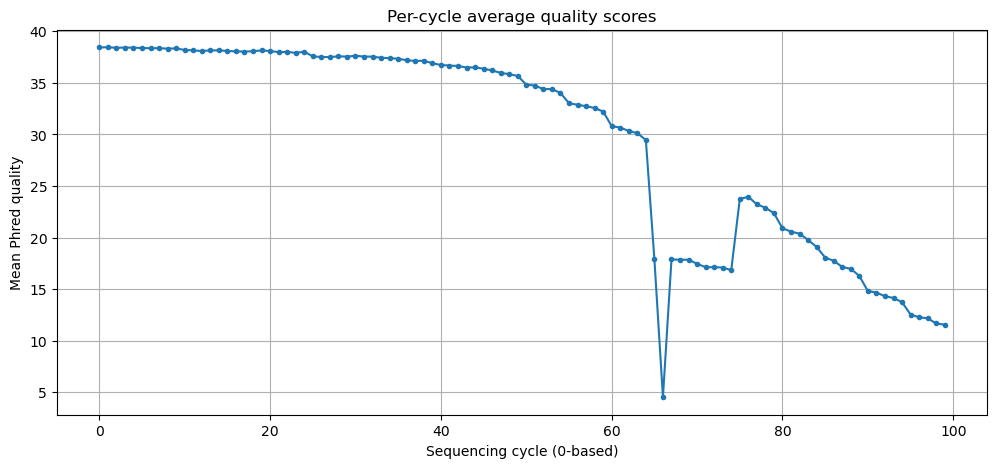

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(mean_per_cycle, marker='o', markersize=3)
plt.xlabel("Sequencing cycle (0-based)")
plt.ylabel("Mean Phred quality")
plt.title("Per-cycle average quality scores")
plt.grid(True)
plt.show()